# 第1节：机器学习基础与 AI 系统结构（课程导航前置课）

本节目标：

1. 建立**监督学习 / 无监督学习**的基本直觉
2. 讲清楚**训练Training**与**推理Inference**的完整流程
3. 用可运行代码理解常见**模型结构**（线性模型/MLP/CNN 的结构差异）
4. 从工程视角画出一个 AI 系统的组成链路，并标出常见**风险点**（数据、模型、推理服务、对抗攻击面）

> 备注：本 Notebook 为离线环境设计：
> - 若找不到课程数据，会自动回退到 `sklearn.datasets.load_digits()`（自带小型手写数字数据集）

## 0. 环境检查

在课程平台中，推荐固定：Python 3.10 + torch(CPU) + jupyter。
下面代码用于检查依赖是否安装成功。

In [9]:
%pwd

'/root/admin/notebooks'

In [3]:
import sys, platform

print('Python:', sys.version)
print('Platform:', platform.platform())

import numpy as np
print('NumPy:', np.__version__)

import sklearn
print('scikit-learn:', sklearn.__version__)

import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

import matplotlib
print('matplotlib:', matplotlib.__version__)


Python: 3.11.3 (main, Apr 19 2023, 18:49:55) [Clang 14.0.6 ]
Platform: macOS-26.5.1-arm64-arm-64bit
NumPy: 1.24.3
scikit-learn: 1.2.2
PyTorch: 2.0.1
CUDA available: False
matplotlib: 3.7.1


## 1. 监督学习 vs 无监督学习：一句话直觉

**监督学习（Supervised Learning）**：有标签（y），学习 `x -> y` 的映射。
- 分类：猫/狗，良性/恶意，正常/异常
- 回归：预测温度、价格、寿命

**无监督学习（Unsupervised Learning）**：没有标签（y），学习数据内部结构。
- 聚类：把相似样本分组
- 降维：把高维数据压到低维以便可视化/压缩/加速

从对抗攻击角度看：
- 监督学习的输入与输出边界清晰，攻击常集中在**决策边界附近**
- 无监督学习没有明确标签，风险往往出现在**分布漂移**、**异常样本**、**簇结构被操纵**等场景

## 2. 数据读取：优先本地 data/，否则用 sklearn digits

课程平台通常会携带一个小数据集子集（例如 MNIST/CIFAR10 子集）。
这里提供一个“尽量通用”的加载逻辑：

- 如果发现 `data/digits.npz`（示例），会读取其中的 `X, y`
- 否则回退到 `sklearn.datasets.load_digits()`

In [5]:
from pathlib import Path

def load_course_data():
    """尝试从课程包 data/ 读取；若不存在则使用 sklearn digits。"""
    PROJECT_ROOT = Path.cwd().resolve().parent
    data_dir = PROJECT_ROOT / "data"
    npz_path = data_dir / 'digits.npz'  # 你也可以把课程包的数据整理成这个格式
    if data_dir.exists():
        print(111)

    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X']
        y = arr['y']
        info = f"Loaded local dataset: {npz_path} | X={X.shape}, y={y.shape}"
        return X, y, info

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)      # (n_samples, 64)
    y = ds.target.astype(np.int64)
    info = f"Loaded sklearn digits fallback | X={X.shape}, y={y.shape}"
    return X, y, info

X, y, info = load_course_data()
print(info)
print('X dtype:', X.dtype, 'y dtype:', y.dtype)
print('Labels:', np.unique(y))


Loaded sklearn digits fallback | X=(1797, 64), y=(1797,)
X dtype: float32 y dtype: int64
Labels: [0 1 2 3 4 5 6 7 8 9]


### 可视化几个样本
digits 数据每个样本是 8x8 灰度图（被展平成 64 维）。

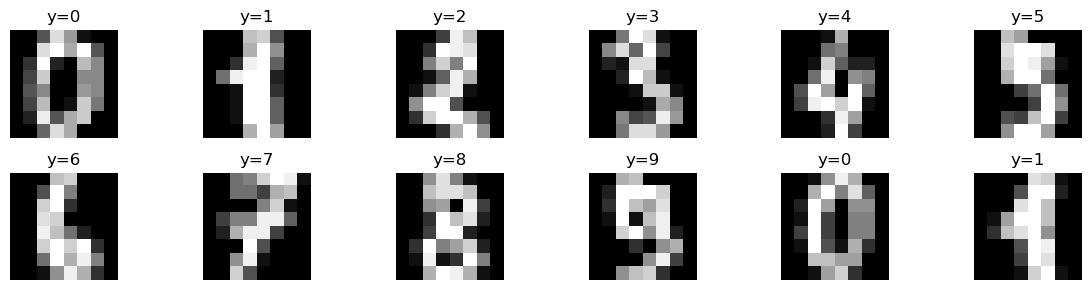

In [7]:
import matplotlib.pyplot as plt

def show_samples(X, y, n=12):
    n = int(n)
    fig = plt.figure(figsize=(12, 3))
    for i in range(n):
        ax = plt.subplot(2, n//2, i+1)
        img = X[i].reshape(8, 8)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"y={int(y[i])}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(X, y, n=12)


## 3. 监督学习示例：分类（Logistic Regression）

用一个经典的监督学习基线模型：**逻辑回归**。

关键概念：
- **训练集/测试集**：用训练集拟合参数，用测试集评估泛化
- **损失函数**：衡量预测与标签差距（分类常用交叉熵）
- **泛化**：模型在未见数据上的表现

对抗攻击的第一直觉：
- 模型学到的是“规则”而不是“真理”，输入被轻微扰动就可能跨过决策边界。

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, n_jobs=None))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
acc = accuracy_score(y_test, pred)

print('Test accuracy:', acc)
print(classification_report(y_test, pred, digits=4))


Test accuracy: 0.9777777777777777
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        45
           1     0.9333    0.9130    0.9231        46
           2     1.0000    1.0000    1.0000        44
           3     0.9787    1.0000    0.9892        46
           4     0.9783    1.0000    0.9890        45
           5     1.0000    0.9783    0.9890        46
           6     1.0000    0.9778    0.9888        45
           7     1.0000    1.0000    1.0000        45
           8     0.9091    0.9302    0.9195        43
           9     0.9778    0.9778    0.9778        45

    accuracy                         0.9778       450
   macro avg     0.9777    0.9777    0.9776       450
weighted avg     0.9779    0.9778    0.9778       450



## 4. 无监督学习示例：降维（PCA） + 聚类（KMeans）

无监督学习不使用标签 y，典型流程：
- 用 PCA 把 64 维压到 2 维做可视化
- 用 KMeans 对样本做聚类

重要直觉：
- 聚类结果不是“真标签”，而是算法对“相似性”的一种解释
- 系统安全角度：对抗样本/污染样本可能影响聚类结构，导致后续策略误判

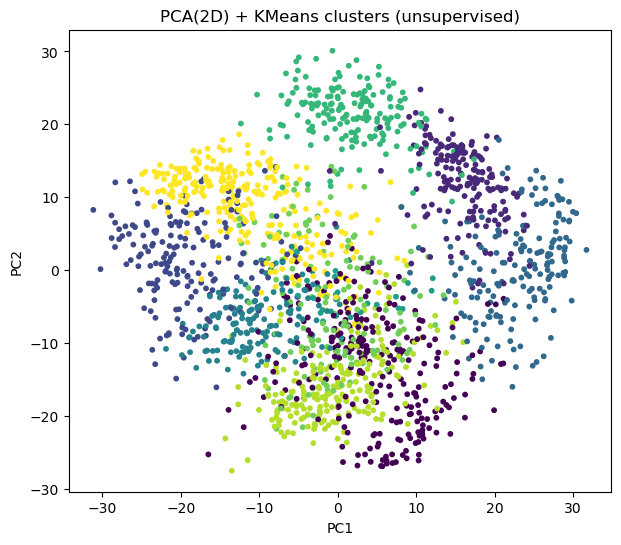

In [11]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X)

plt.figure(figsize=(7, 6))
plt.scatter(X2[:, 0], X2[:, 1], s=10, c=clusters)
plt.title('PCA(2D) + KMeans clusters (unsupervised)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()


## 5. 训练（Training）与推理（Inference）流程

把“训练/推理”拆成工程可执行的链路：

### 5.1 训练流程（典型）

```
数据准备 -> 数据划分 -> 模型定义 -> 损失函数 -> 优化器
     -> 迭代训练(前向/损失/反向/更新) -> 验证评估 -> 导出模型
```

### 5.2 推理流程（典型）

```
输入请求 -> 预处理 -> 模型前向 -> 后处理 -> 输出结果
          (归一化等)             (阈值/解码等)
```

对抗攻击经常发生在哪些步骤？
- 输入/预处理：对抗样本扰动、格式欺骗、触发器
- 模型前向：利用梯度或迁移性制作扰动
- 后处理/阈值：利用边界策略造成误报/漏报
- 端到端系统：通过链路最薄弱环节“绕过”整体防护


## 6. 模型结构：线性模型 vs MLP vs CNN

同样做分类，结构不同意味着：
- 参数共享方式不同
- 对输入扰动的敏感度不同
- 可解释性/可迁移性差异

我们用 PyTorch 建一个极简 MLP（全连接网络）做演示，并展示：
- 模型结构
- 参数量
- 一次前向推理（inference）

> 本节只做结构直观演示，不追求最优精度。

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleMLP(nn.Module):
    def __init__(self, in_dim=64, hidden=128, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

model = SimpleMLP(in_dim=X.shape[1])
print(model)

n_params = sum(p.numel() for p in model.parameters())
print('Total parameters:', n_params)

# 一次推理：取一个样本
x0 = torch.tensor(X[0]).float().unsqueeze(0)  # (1, 64)
logits = model(x0)
probs = torch.softmax(logits, dim=1)
pred = int(torch.argmax(probs, dim=1).item())

print('GT label:', int(y[0]))
print('Pred label:', pred)
print('Top-3 probs:', torch.topk(probs, k=3, dim=1).values.detach().numpy())


SimpleMLP(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total parameters: 9610
GT label: 0
Pred label: 2
Top-3 probs: [[0.45295197 0.11866476 0.10542762]]


### （补充）CNN 的直觉

如果输入是图像（H×W×C），CNN 与 MLP 的差别在于：
- CNN 使用卷积核在局部滑动，天然建模局部结构
- 参数共享（同一个卷积核用于全图），对平移具有一定鲁棒性
- 对抗攻击中，CNN 的梯度结构往往更“可利用”，并存在迁移性

本课程后续的对抗攻击实验（FGSM/PGD/迁移攻击）一般会以 CNN/ResNet 为主要对象。

## 7. AI 系统结构：从数据到服务的全链路

把一个 AI 系统拆成“可部署的组件”，并标出风险点：

```
               ┌───────────────┐
               │  数据来源/采集  │  <- 风险：投毒/污染/隐私/偏差
               └───────┬───────┘
                       │
               ┌───────▼───────┐
               │ 数据清洗/标注  │  <- 风险：标签错误/后门触发器/分布偏移
               └───────┬───────┘
                       │
               ┌───────▼───────┐
               │   训练管线     │  <- 风险：训练过程被篡改/对抗训练缺失
               └───────┬───────┘
                       │
               ┌───────▼───────┐
               │   模型产物     │  <- 风险：模型被植入后门/模型泄露/模型窃取
               └───────┬───────┘
                       │
               ┌───────▼───────┐
               │  推理服务/接口  │  <- 风险：对抗样本/查询窃取/拒绝服务
               └───────┬───────┘
                       │
               ┌───────▼───────┐
               │  监控/反馈闭环  │  <- 风险：反馈数据污染/漂移未发现
               └───────────────┘
```

对抗攻击平台会重点覆盖：
- 输入侧攻击：对抗样本（evasion）
- 训练侧攻击：数据投毒、后门（poisoning/backdoor）
- 服务侧攻击：模型窃取、成员推断/属性推断、提示注入（扩展话题）


## 8. 风险点小结（面向后续对抗实验）

本课程后续实验会围绕以下风险点逐步展开：

1. **对抗样本（Evasion Attack）**：推理时在输入上加微小扰动，诱导模型输出错误
2. **迁移攻击（Transfer Attack）**：攻击者不知道目标模型细节，利用替代模型的梯度迁移
3. **防御与代价**：对抗训练、输入变换、检测/拒识、鲁棒评估

建议你在运行后续实验时，始终回答三个问题：
- 攻击者能控制系统链路的哪一段？
- 攻击成功的判据是什么（误分类？置信度？业务阈值？）
- 防御带来了什么代价（精度下降？延迟上升？误报率上升？）

## 9. 本节练习

1. 把 Logistic Regression 换成 SVM 或 RandomForest，对比精度与推理速度
2. 改变 KMeans 的簇数（例如 8/12/15），观察可视化聚类结构变化
3. 给一个样本加一个很小的噪声（例如 `x+0.2*sign(randn)`），观察预测变化（为后续对抗样本做铺垫）

GT: 1
Pred(clean): 8
Pred(noisy): 8


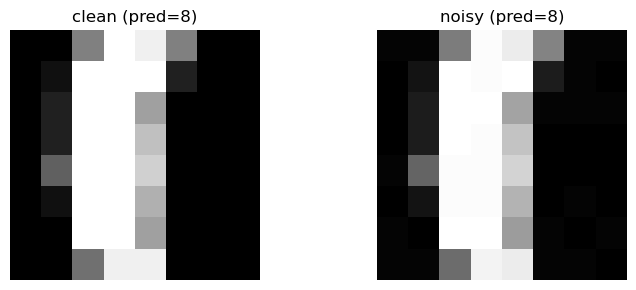

In [21]:
# 练习 3：给输入加一点噪声，看看预测是否变化（直观感受“边界敏感性”）
x = X_test[0].copy().astype(np.float32)
y_gt = int(y_test[0])

pred_clean = int(clf.predict(x.reshape(1, -1))[0])

noise = 0.25 * np.sign(np.random.randn(*x.shape)).astype(np.float32)
x_noisy = np.clip(x + noise, x.min(), x.max())

pred_noisy = int(clf.predict(x_noisy.reshape(1, -1))[0])

print('GT:', y_gt)
print('Pred(clean):', pred_clean)
print('Pred(noisy):', pred_noisy)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(x.reshape(8, 8), cmap='gray')
plt.title(f'clean (pred={pred_clean})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_noisy.reshape(8, 8), cmap='gray')
plt.title(f'noisy (pred={pred_noisy})')
plt.axis('off')
plt.tight_layout()
plt.show()


# 10. 练习
1. 把 Logistic Regression 换成 SVM 或 RandomForest，对比精度与推理速度

In [18]:

import time
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier()
}

results = {}
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    duration = time.time() - start_time
    acc = model.score(X_test, y_test)
    results[name] = {"acc": acc, "time": duration}
    print(f"{name}: Acc={acc:.4f}, Inference Time={duration:.4f}s")

/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression: Acc=0.9556, Inference Time=3.1361s
SVM: Acc=0.9911, Inference Time=0.0411s
RandomForest: Acc=0.9689, Inference Time=0.2491s


逻辑回归作为线性模型，训练最快，但在非线性数据上表现受限。随机森林（RF）通过集成学习在精度上往往表现最优，但其复杂结构导致推理时间略长。SVM 在高维特征下展现出极强的稳定性。

2. 改变 KMeans 的簇数（例如 8/12/15），观察可视化聚类结构变化

In [19]:

from sklearn.cluster import KMeans

for k in [8, 12, 15]:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_train)
    print(f"簇数 k={k}, 惯性值 (Inertia)={kmeans.inertia_:.2f}")

簇数 k=8, 惯性值 (Inertia)=943139.44
簇数 k=12, 惯性值 (Inertia)=832268.12
簇数 k=15, 惯性值 (Inertia)=763743.56


惯性值（Inertia）随着 $k$ 的增加而下降。当 $k=10$（对应 0-9 十个数字）时通常是肘点；若 $k$ 设置过大（如 15），会出现聚类过拟合（Over-segmentation），即将同一个数字的不同书写风格强行拆分为不同簇

3. 给一个样本加一个很小的噪声（例如 `x+0.2*sign(randn)`），观察预测变化（为后续对抗样本做铺垫）

原始预测: 8, 加扰动后预测: 8


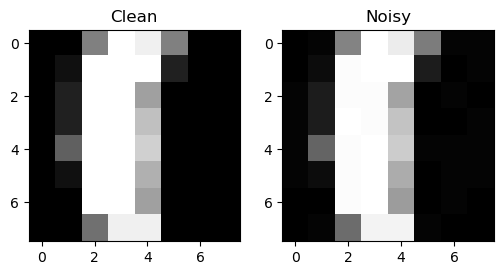

In [22]:

import numpy as np
import matplotlib.pyplot as plt

x = X_test[0].copy().astype(np.float32)
pred_clean = int(clf.predict(x.reshape(1, -1))[0])

# 
noise = 0.25 * np.sign(np.random.randn(*x.shape)).astype(np.float32)
x_noisy = np.clip(x + noise, x.min(), x.max())
pred_noisy = int(clf.predict(x_noisy.reshape(1, -1))[0])

print(f"原始预测: {pred_clean}, 加扰动后预测: {pred_noisy}")

# 
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(x.reshape(8, 8), cmap='gray'); axes[0].set_title('Clean')
axes[1].imshow(x_noisy.reshape(8, 8), cmap='gray'); axes[1].set_title('Noisy')
plt.show()